In [1]:

# CHECKERS LLM BENCHMARK
# Install Ollama + Load Models from Google Drive

import subprocess
import time
import os

# --- Install zstd ---
print(" Installing zstd...")
subprocess.run(['apt-get', 'install', '-y', 'zstd'],
               capture_output=True)
print(" zstd installed")

# --- Install Ollama ---
print("\n Installing Ollama...")
subprocess.run(
    'curl -fsSL https://ollama.com/install.sh | sh',
    shell=True, capture_output=True
)
print("Ollama installed")

# --- Start Ollama Server ---
print("\n Starting Ollama server...")
subprocess.Popen(
    ['ollama', 'serve'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(6)
print(" Ollama server running!")

# --- Mount SECOND Google Drive (everything here) ---
from google.colab import drive
print("\n Mounting Google Drive...")
drive.mount('/content/drive')
print(" Google Drive mounted!")

# --- All Folders ---
PROJECT_FOLDER      = "/content/drive/MyDrive/checkers_benchmark"
RESULTS_FOLDER      = f"{PROJECT_FOLDER}/results"
DRIVE_MODELS_FOLDER = f"{PROJECT_FOLDER}/ollama_models"
LOCAL_MODELS_FOLDER = os.path.expanduser("~/.ollama")

os.makedirs(RESULTS_FOLDER,      exist_ok=True)
os.makedirs(DRIVE_MODELS_FOLDER, exist_ok=True)

print(f"\n Project folder : {PROJECT_FOLDER}")
print(f" Results folder : {RESULTS_FOLDER}")
print(f" Models folder  : {DRIVE_MODELS_FOLDER}")

# --- Models List ---
MODELS_LIST = ['llama3.2:3b', 'mistral:7b', 'qwen2.5:7b']

for model in MODELS_LIST:
    model_safe_name  = model.replace(":", "_")
    drive_model_path = f"{DRIVE_MODELS_FOLDER}/{model_safe_name}"

    # Check if model already saved in Drive
    if os.path.exists(drive_model_path):
        print(f"\n Loading {model} from Drive...")
        subprocess.run(
            f"cp -r {drive_model_path}/. {LOCAL_MODELS_FOLDER}/",
            shell=True
        )
        print(f" {model} loaded from Drive!")

    else:
        print(f"\n {model} not found — downloading for first time...")
        subprocess.run(['ollama', 'pull', model], check=True)

        # Save to Drive for future use
        print(f" Saving {model} to Drive for next time...")
        os.makedirs(drive_model_path, exist_ok=True)
        subprocess.run(
            f"cp -r {LOCAL_MODELS_FOLDER}/. {drive_model_path}/",
            shell=True
        )
        print(f" {model} saved to Drive!")

# --- Verify ---
print("\n Verifying installed models:")
result = subprocess.run(['ollama', 'list'],
                        capture_output=True, text=True)
print(result.stdout)
print("\n All models ready!")

 Installing zstd...
 zstd installed

 Installing Ollama...
Ollama installed

 Starting Ollama server...
 Ollama server running!

 Mounting Google Drive...
Mounted at /content/drive
 Google Drive mounted!

 Project folder : /content/drive/MyDrive/checkers_benchmark
 Results folder : /content/drive/MyDrive/checkers_benchmark/results
 Models folder  : /content/drive/MyDrive/checkers_benchmark/ollama_models

 Loading llama3.2:3b from Drive...
 llama3.2:3b loaded from Drive!

 Loading mistral:7b from Drive...
 mistral:7b loaded from Drive!

 Loading qwen2.5:7b from Drive...
 qwen2.5:7b loaded from Drive!

 Verifying installed models:
NAME           ID              SIZE      MODIFIED               
qwen2.5:7b     845dbda0ea48    4.7 GB    Less than a second ago    
llama3.2:3b    a80c4f17acd5    2.0 GB    Less than a second ago    
mistral:7b     6577803aa9a0    4.4 GB    Less than a second ago    


 All models ready!


In [2]:
# Libraries and Model Setup

import os
import re
import copy
import time
import json
import random
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# --- Install Ollama Python Library ---
subprocess.run(["pip", "install", "ollama", "-q"], check=True)
import ollama

# --- Model Lineup ---
MODELS = {
    "LLaMA 3.2 3B" : "llama3.2:3b",
    "Mistral 7B"   : "mistral:7b",
    "Qwen 2.5 7B"  : "qwen2.5:7b"
}

# --- Quick Connection Test ---
print("Testing all 3 models...\n")
for name, model_id in MODELS.items():
    try:
        # Qwen uses generate endpoint
        if "qwen" in model_id.lower():
            response = ollama.generate(
                model   = model_id,
                prompt  = "Say: connected!",
                options = {"temperature": 0.1}
            )
            print(f" {name}: connected!")

        # LLaMA and Mistral use chat endpoint
        else:
            response = ollama.chat(
                model    = model_id,
                messages = [{"role": "user", "content": "Say: connected!"}]
            )
            print(f" {name}: connected!")

    except Exception as e:
        print(f" {name} failed: {str(e)}")

print("\n All libraries loaded!")
print(f" Results will be saved to : {RESULTS_FOLDER}")
print(f" Models loaded from       : {DRIVE_MODELS_FOLDER}")

Testing all 3 models...

 LLaMA 3.2 3B: connected!
 Mistral 7B: connected!
 Qwen 2.5 7B: connected!

 All libraries loaded!
 Results will be saved to : /content/drive/MyDrive/checkers_benchmark/results
 Models loaded from       : /content/drive/MyDrive/checkers_benchmark/ollama_models


In [3]:

# Checkers Engine
# (Board Setup, Move Generation, Apply Moves, Winner Check)

# --- Piece Definitions ---
EMPTY      = 0
RED        = 1       # LLM plays as RED (moves upward)
BLACK      = 2       # Random opponent plays as BLACK (moves downward)
RED_KING   = 3       # RED piece promoted to king
BLACK_KING = 4       # BLACK piece promoted to king

# ----------------------------------------
# Board Setup
# ----------------------------------------

def create_board():
    """
    Creates the initial 8x8 checkers board.
    BLACK pieces start at top (rows 0-2).
    RED pieces start at bottom (rows 5-7).
    Pieces placed only on dark squares (odd sum of row+col).
    """
    board = [[EMPTY] * 8 for _ in range(8)]

    for row in range(3):
        for col in range(8):
            if (row + col) % 2 == 1:
                board[row][col] = BLACK

    for row in range(5, 8):
        for col in range(8):
            if (row + col) % 2 == 1:
                board[row][col] = RED

    return board

def print_board(board):
    """
    Prints the board in a human readable format.
    r = RED, b = BLACK, R = RED KING, B = BLACK KING, . = EMPTY
    """
    print("\n  0 1 2 3 4 5 6 7")
    print("  ---------------")
    for row in range(8):
        print(f"{row}|", end=" ")
        for col in range(8):
            piece = board[row][col]
            if piece == EMPTY:         symbol = "."
            elif piece == RED:         symbol = "r"
            elif piece == BLACK:       symbol = "b"
            elif piece == RED_KING:    symbol = "R"
            elif piece == BLACK_KING:  symbol = "B"
            print(symbol, end=" ")
        print()
    print()

# ----------------------------------------
# Move Generation
# ----------------------------------------

def get_valid_moves(board, player):
    """
    Returns all valid moves for the given player.
    Capture moves are mandatory — if any exist,
    only capture moves are returned.
    """
    moves    = []
    captures = []

    for row in range(8):
        for col in range(8):
            piece = board[row][col]

            if player == RED   and piece not in (RED, RED_KING):    continue
            if player == BLACK and piece not in (BLACK, BLACK_KING): continue

            if piece == RED:                     directions = [(-1, -1), (-1, 1)]
            elif piece == BLACK:                 directions = [(1, -1),  (1, 1)]
            elif piece in (RED_KING, BLACK_KING): directions = [(-1,-1),(-1,1),(1,-1),(1,1)]

            for dr, dc in directions:
                new_row, new_col = row + dr, col + dc

                if 0 <= new_row < 8 and 0 <= new_col < 8:
                    if board[new_row][new_col] == EMPTY:
                        moves.append({
                            "from"   : (row, col),
                            "to"     : (new_row, new_col),
                            "capture": None
                        })
                    else:
                        target   = board[new_row][new_col]
                        jump_row = row + 2*dr
                        jump_col = col + 2*dc

                        is_opponent = (
                            player == RED   and target in (BLACK, BLACK_KING) or
                            player == BLACK and target in (RED, RED_KING)
                        )

                        if (is_opponent and
                            0 <= jump_row < 8 and
                            0 <= jump_col < 8 and
                            board[jump_row][jump_col] == EMPTY):

                            captures.append({
                                "from"   : (row, col),
                                "to"     : (jump_row, jump_col),
                                "capture": (new_row, new_col)
                            })

    return captures if captures else moves

# ----------------------------------------
# Apply Move and King Promotion
# ----------------------------------------

def apply_move(board, move):
    """
    Applies a move to the board and returns a new board.
    Handles normal moves, captures, and king promotion.
    """
    new_board = copy.deepcopy(board)

    from_row, from_col = move["from"]
    to_row,   to_col   = move["to"]

    new_board[to_row][to_col]     = new_board[from_row][from_col]
    new_board[from_row][from_col] = EMPTY

    if move["capture"]:
        cap_row, cap_col = move["capture"]
        new_board[cap_row][cap_col] = EMPTY

    if new_board[to_row][to_col] == RED   and to_row == 0:
        new_board[to_row][to_col] = RED_KING
        print(f"    RED promoted to KING at ({to_row},{to_col})!")

    if new_board[to_row][to_col] == BLACK and to_row == 7:
        new_board[to_row][to_col] = BLACK_KING
        print(f"    BLACK promoted to KING at ({to_row},{to_col})!")

    return new_board

# ----------------------------------------
# Winner Check
# ----------------------------------------

def check_winner(board):
    """
    Returns 'RED', 'BLACK', or None if game is ongoing.
    """
    red_pieces   = sum(row.count(RED)   + row.count(RED_KING)   for row in board)
    black_pieces = sum(row.count(BLACK) + row.count(BLACK_KING) for row in board)

    if black_pieces == 0:                  return "RED"
    if red_pieces   == 0:                  return "BLACK"
    if not get_valid_moves(board, RED):    return "BLACK"
    if not get_valid_moves(board, BLACK):  return "RED"

    return None

# ----------------------------------------
# Random Opponent
# ----------------------------------------

def random_opponent_move(board):
    """
    Generates a random move for BLACK (opponent).
    Captures are mandatory so they are prioritized.
    """
    valid_moves = get_valid_moves(board, BLACK)
    if not valid_moves:
        return None
    return random.choice(valid_moves)

# ----------------------------------------
# Board to Text Renderer
# ----------------------------------------

def board_to_text(board, player, valid_moves):
    """
    Converts board state to text prompt for the LLM.
    """
    text  = "=== CHECKERS GAME ===\n\n"
    text += "LEGEND:\n"
    text += "  r = your piece (RED)\n"
    text += "  R = your KING (RED KING)\n"
    text += "  b = opponent (BLACK)\n"
    text += "  B = opponent KING (BLACK KING)\n"
    text += "  . = empty square\n\n"
    text += "CURRENT BOARD (row, col):\n"
    text += "  0 1 2 3 4 5 6 7\n"
    text += "  ---------------\n"

    for row in range(8):
        text += f"{row}| "
        for col in range(8):
            piece = board[row][col]
            if piece == EMPTY:         symbol = "."
            elif piece == RED:         symbol = "r"
            elif piece == BLACK:       symbol = "b"
            elif piece == RED_KING:    symbol = "R"
            elif piece == BLACK_KING:  symbol = "B"
            text += symbol + " "
        text += "\n"

    text += f"\nYou are RED — moves go UPWARD (toward row 0).\n"
    text += f"\nYOUR VALID MOVES ({len(valid_moves)} available):\n"

    for i, move in enumerate(valid_moves):
        fr, fc = move["from"]
        tr, tc = move["to"]
        if move["capture"]:
            cr, cc = move["capture"]
            text += f"  Move {i+1}: ({fr},{fc}) --> ({tr},{tc}) [CAPTURE piece at ({cr},{cc})]\n"
        else:
            text += f"  Move {i+1}: ({fr},{fc}) --> ({tr},{tc})\n"

    text += "\nINSTRUCTIONS:\n"
    text += "1. Analyze the board carefully.\n"
    text += "2. Explain your reasoning step by step.\n"
    text += "3. Choose the best move from the valid moves list.\n"
    text += "4. End your response with EXACTLY this format:\n"
    text += "   MOVE: (from_row,from_col) --> (to_row,to_col)\n"
    text += "   Example: MOVE: (5,2) --> (4,3)\n"

    return text


# --- Test Engine ---
print("Testing Checkers Engine...\n")
board = create_board()
print_board(board)

moves = get_valid_moves(board, RED)
print(f"RED has {len(moves)} valid moves at start:")
for m in moves:
    print(f"   {m['from']} --> {m['to']}")

print("\n Checkers Engine ready!")

Testing Checkers Engine...


  0 1 2 3 4 5 6 7
  ---------------
0| . b . b . b . b 
1| b . b . b . b . 
2| . b . b . b . b 
3| . . . . . . . . 
4| . . . . . . . . 
5| r . r . r . r . 
6| . r . r . r . r 
7| r . r . r . r . 

RED has 7 valid moves at start:
   (5, 0) --> (4, 1)
   (5, 2) --> (4, 1)
   (5, 2) --> (4, 3)
   (5, 4) --> (4, 3)
   (5, 4) --> (4, 5)
   (5, 6) --> (4, 5)
   (5, 6) --> (4, 7)

 Checkers Engine ready!


In [4]:

# LLM Move Parser and Ollama Move Function

def parse_llm_move(response_text, valid_moves):
    """
    Parses the LLM response and extracts the chosen move.
    Handles:
        - Qwen thinking tags
        - Flexible spacing in MOVE format
        - Validates against legal moves
    Returns matched move dict or None if not found.
    """
    # Strip Qwen thinking tags
    response_text = re.sub(
        r"<think>.*?</think>",
        "",
        response_text,
        flags=re.DOTALL
    ).strip()

    # Look for MOVE pattern
    pattern = r"MOVE:\s*\((\d+)\s*,\s*(\d+)\)\s*-->\s*\((\d+)\s*,\s*(\d+)\)"
    match   = re.search(pattern, response_text)

    if not match:
        print(" Could not find MOVE pattern in LLM response!")
        return None

    # Extract coordinates
    fr = int(match.group(1))
    fc = int(match.group(2))
    tr = int(match.group(3))
    tc = int(match.group(4))

    # Validate against valid moves
    for move in valid_moves:
        if move["from"] == (fr, fc) and move["to"] == (tr, tc):
            return move

    print(f" LLM chose invalid move: ({fr},{fc}) --> ({tr},{tc})")
    return None


def get_llm_move(model_id, board, valid_moves):
    """
    Sends board state to LLM via Ollama and gets its move.
    Fully local — no API keys, no rate limits.
    Returns move dict and raw response text.
    """
    prompt = board_to_text(board, RED, valid_moves)

    system_prompt = """You are an expert Checkers player.
You will be given a board state and a list of valid moves.
You must analyze the board carefully and choose the best move.
Always end your response with EXACTLY this format:
MOVE: (from_row,from_col) --> (to_row,to_col)
Example: MOVE: (5,2) --> (4,3)"""

    response = ollama.chat(
        model    = model_id,
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": prompt}
        ],
        options  = {"temperature": 0.1}
    )

    response_text = response["message"]["content"]
    move          = parse_llm_move(response_text, valid_moves)
    return move, response_text


# --- Test with all 3 models ---
print("Testing LLM move generation with all 3 models...\n")

board       = create_board()
valid_moves = get_valid_moves(board, RED)

print("Available valid moves:")
for m in valid_moves:
    print(f"   {m['from']} --> {m['to']}")
print()

for name, model_id in MODELS.items():
    move, response = get_llm_move(model_id, board, valid_moves)
    print(f" {name}: {move}")

print("\n LLM Move Parser ready!")

Testing LLM move generation with all 3 models...

Available valid moves:
   (5, 0) --> (4, 1)
   (5, 2) --> (4, 1)
   (5, 2) --> (4, 3)
   (5, 4) --> (4, 3)
   (5, 4) --> (4, 5)
   (5, 6) --> (4, 5)
   (5, 6) --> (4, 7)

 LLaMA 3.2 3B: {'from': (5, 2), 'to': (4, 1), 'capture': None}
 Mistral 7B: {'from': (5, 2), 'to': (4, 3), 'capture': None}
 Qwen 2.5 7B: {'from': (5, 0), 'to': (4, 1), 'capture': None}

 LLM Move Parser ready!


In [5]:

# Single Game Runner

def play_single_game(model_id, model_name, game_number, max_moves=100):
    """
    Plays a single full game between an LLM (RED) and
    the random opponent (BLACK).
    Tracks all metrics for evaluation.
    Returns a dict with full game statistics.
    """
    board        = create_board()
    current_turn = RED
    move_count   = 0

    # --- Metrics ---
    total_moves     = 0
    illegal_moves   = 0
    captures_made   = 0
    missed_captures = 0
    reasoning_log   = []

    print(f"\n{'='*50}")
    print(f"Game {game_number} | Model: {model_name}")
    print(f"{'='*50}")

    while move_count < max_moves:
        winner = check_winner(board)
        if winner:
            break

        valid_moves = get_valid_moves(board, current_turn)
        if not valid_moves:
            winner = "BLACK" if current_turn == RED else "RED"
            break

        # --- RED turn (LLM) ---
        if current_turn == RED:
            move, response_text = get_llm_move(model_id, board, valid_moves)

            # Fallback to random if LLM fails
            if move is None:
                illegal_moves += 1
                print(f"  Move {move_count+1}: LLM failed — using random fallback.")
                move = random.choice(valid_moves)

            # Track captures
            if move["capture"]:
                captures_made += 1

            # Track missed captures
            has_captures = any(m["capture"] for m in valid_moves)
            if has_captures and not move["capture"]:
                missed_captures += 1

            # Log reasoning
            reasoning_log.append({
                "move_number" : move_count + 1,
                "reasoning"   : response_text[:200]
            })

            fr, fc = move["from"]
            tr, tc = move["to"]
            print(f"   Move {move_count+1} | RED  (LLM)   : ({fr},{fc}) --> ({tr},{tc})"
                  + (" [CAPTURE]" if move["capture"] else ""))

        # --- BLACK turn (Random) ---
        else:
            move = random_opponent_move(board)
            if move is None:
                winner = "RED"
                break

            fr, fc = move["from"]
            tr, tc = move["to"]
            print(f"   Move {move_count+1} | BLACK (Random): ({fr},{fc}) --> ({tr},{tc})"
                  + (" [CAPTURE]" if move["capture"] else ""))

        board        = apply_move(board, move)
        current_turn = BLACK if current_turn == RED else RED
        move_count  += 1
        total_moves += 1

    if not winner:
        winner = "DRAW"

    print(f"\n Game {game_number} Result: {winner} wins!")
    print(f"   Total moves    : {total_moves}")
    print(f"   Illegal moves  : {illegal_moves}")
    print(f"   Captures made  : {captures_made}")
    print(f"   Missed captures: {missed_captures}")

    return {
        "model_name"      : model_name,
        "game_number"     : game_number,
        "winner"          : winner,
        "total_moves"     : total_moves,
        "illegal_moves"   : illegal_moves,
        "captures_made"   : captures_made,
        "missed_captures" : missed_captures,
        "reasoning_log"   : reasoning_log
    }


# --- Test Single Game ---
print("Running a single test game with LLaMA 3.2 3B...\n")

result = play_single_game(
    model_id    = MODELS["LLaMA 3.2 3B"],
    model_name  = "LLaMA 3.2 3B",
    game_number = 1
)

print(f"\n Single game test complete!")
print(f"   Winner : {result['winner']}")
print(f"   Moves  : {result['total_moves']}")

Running a single test game with LLaMA 3.2 3B...


Game 1 | Model: LLaMA 3.2 3B
   Move 1 | RED  (LLM)   : (5,2) --> (4,3)
   Move 2 | BLACK (Random): (2,1) --> (3,2)
   Move 3 | RED  (LLM)   : (4,3) --> (2,1) [CAPTURE]
   Move 4 | BLACK (Random): (1,2) --> (3,0) [CAPTURE]
   Move 5 | RED  (LLM)   : (5,4) --> (4,3)
   Move 6 | BLACK (Random): (2,3) --> (3,2)
   Move 7 | RED  (LLM)   : (4,3) --> (2,1) [CAPTURE]
   Move 8 | BLACK (Random): (1,0) --> (3,2) [CAPTURE]
 LLM chose invalid move: (6,5) --> (4,7)
  Move 9: LLM failed — using random fallback.
   Move 9 | RED  (LLM)   : (6,3) --> (5,2)
   Move 10 | BLACK (Random): (2,5) --> (3,6)
   Move 11 | RED  (LLM)   : (5,2) --> (4,3)
   Move 12 | BLACK (Random): (3,2) --> (5,4) [CAPTURE]
   Move 13 | RED  (LLM)   : (6,5) --> (4,3) [CAPTURE]
   Move 14 | BLACK (Random): (0,1) --> (1,2)
   Move 15 | RED  (LLM)   : (5,0) --> (4,1)
   Move 16 | BLACK (Random): (3,0) --> (5,2) [CAPTURE]
   Move 17 | RED  (LLM)   : (4,3) --> (3,2)
   Move 18 | BLAC

In [6]:
# Full Benchmark Runner

def get_completed_games(model_name):
    """
    Checks how many games are already saved for a model.
    Returns count of completed games and existing results.
    """
    save_path = f"{RESULTS_FOLDER}/{model_name.replace(' ', '_')}_results.json"

    if not os.path.exists(save_path):
        return 0, []

    with open(save_path, "r") as f:
        results = json.load(f)

    return len(results), results


def run_benchmark_resume(model_name, model_id, num_games=20):
    """
    Resume aware benchmark runner.
    Checks how many games are already done and
    continues from where it left off.
    Skips model completely if already finished.
    """
    save_path          = f"{RESULTS_FOLDER}/{model_name.replace(' ', '_')}_results.json"
    completed, all_results = get_completed_games(model_name)

    # Skip if already complete
    if completed >= num_games:
        print(f"\n {model_name} already complete! ({completed}/{num_games} games done) — Skipping!")
        return all_results

    print(f"\n{'='*60}")
    print(f"RESUMING : {model_name}")
    print(f"Completed: {completed}/{num_games} games")
    print(f"Remaining: {num_games - completed} games")
    print(f"{'='*60}")

    for game_num in range(completed + 1, num_games + 1):
        result = play_single_game(
            model_id    = model_id,
            model_name  = model_name,
            game_number = game_num
        )

        # Remove reasoning log before saving
        result_to_save = {k: v for k, v in result.items()
                         if k != "reasoning_log"}
        all_results.append(result_to_save)

        # Save after every game
        with open(save_path, "w") as f:
            json.dump(all_results, f, indent=2)

        wins   = sum(1 for r in all_results if r["winner"] == "RED")
        losses = sum(1 for r in all_results if r["winner"] == "BLACK")
        draws  = sum(1 for r in all_results if r["winner"] == "DRAW")

        print(f"\n Saved to Google Drive!")
        print(f" Score after game {game_num}: "
              f"Wins={wins} | Losses={losses} | Draws={draws}")

    print(f"\n {model_name} benchmark complete!")
    print(f"   Total games : {num_games}")
    print(f"   Final score : Wins={wins} | Losses={losses} | Draws={draws}")

    return all_results


# Check current progress first

print(" Checking current progress in Google Drive...\n")
for name in MODELS.keys():
    count, _ = get_completed_games(name)
    print(f"   {name}: {count}/20 games completed")

print("\n Starting/Resuming benchmarks...\n")

all_benchmark_results = {}

# --- Model 1: LLaMA 3.2 3B ---
all_benchmark_results["LLaMA 3.2 3B"] = run_benchmark_resume(
    model_name = "LLaMA 3.2 3B",
    model_id   = MODELS["LLaMA 3.2 3B"],
    num_games  = 20
)

# --- Model 2: Mistral 7B ---
all_benchmark_results["Mistral 7B"] = run_benchmark_resume(
    model_name = "Mistral 7B",
    model_id   = MODELS["Mistral 7B"],
    num_games  = 20
)

# --- Model 3: Qwen 2.5 7B ---
all_benchmark_results["Qwen 2.5 7B"] = run_benchmark_resume(
    model_name = "Qwen 2.5 7B",
    model_id   = MODELS["Qwen 2.5 7B"],
    num_games  = 20
)

print("\n ALL BENCHMARKS COMPLETE!")
print(f"   Total games played : 60")
print(f"   Results saved to   : {RESULTS_FOLDER}")

 Checking current progress in Google Drive...

   LLaMA 3.2 3B: 20/20 games completed
   Mistral 7B: 20/20 games completed
   Qwen 2.5 7B: 20/20 games completed

 Starting/Resuming benchmarks...


 LLaMA 3.2 3B already complete! (20/20 games done) — Skipping!

 Mistral 7B already complete! (20/20 games done) — Skipping!

 Qwen 2.5 7B already complete! (20/20 games done) — Skipping!

 ALL BENCHMARKS COMPLETE!
   Total games played : 60
   Results saved to   : /content/drive/MyDrive/checkers_benchmark/results


In [10]:
# ANALYSIS AND CHARTS


import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive


print(f" Results folder: {RESULTS_FOLDER}\n")

# --- Load all 3 result files ---
print(" Loading results...\n")

all_results = {}
model_files = {
    "LLaMA 3.2 3B" : "LLaMA_3.2_3B_results.json",
    "Mistral 7B"   : "Mistral_7B_results.json",
    "Qwen 2.5 7B"  : "Qwen_2.5_7B_results.json"
}

for model_name, filename in model_files.items():
    filepath = f"{RESULTS_FOLDER}/{filename}"

    if os.path.exists(filepath):
        with open(filepath, "r") as f:
            all_results[model_name] = json.load(f)
        print(f" {model_name}: {len(all_results[model_name])} games loaded")
    else:
        print(f" {model_name}: file not found at {filepath}")

# --- Build Summary DataFrame ---
print("\n Building summary table...\n")

summary = []
for model_name, results in all_results.items():
    wins          = sum(1 for r in results if r["winner"] == "RED")
    losses        = sum(1 for r in results if r["winner"] == "BLACK")
    draws         = sum(1 for r in results if r["winner"] == "DRAW")
    total_games   = len(results)
    win_rate      = round(wins / total_games * 100, 1)
    avg_moves     = round(sum(r["total_moves"] for r in results) / total_games, 1)
    avg_captures  = round(sum(r["captures_made"] for r in results) / total_games, 1)
    total_illegal = sum(r["illegal_moves"] for r in results)
    total_missed  = sum(r["missed_captures"] for r in results)

    summary.append({
        "Model"           : model_name,
        "Wins"            : wins,
        "Losses"          : losses,
        "Draws"           : draws,
        "Win Rate (%)"    : win_rate,
        "Avg Moves"       : avg_moves,
        "Avg Captures"    : avg_captures,
        "Illegal Moves"   : total_illegal,
        "Missed Captures" : total_missed
    })

df = pd.DataFrame(summary)

print("=" * 75)
print(df.to_string(index=False))
print("=" * 75)

print("\n Results loaded and summary table ready!")

 Results folder: /content/drive/MyDrive/checkers_benchmark/results

 Loading results...

 LLaMA 3.2 3B: 20 games loaded
 Mistral 7B: 20 games loaded
 Qwen 2.5 7B: 20 games loaded

 Building summary table...

       Model  Wins  Losses  Draws  Win Rate (%)  Avg Moves  Avg Captures  Illegal Moves  Missed Captures
LLaMA 3.2 3B     6       6      8          30.0       79.8          10.1             23                0
  Mistral 7B     8       9      3          40.0       68.3           9.6             43                0
 Qwen 2.5 7B     4      10      6          20.0       68.2           9.1              4                0

 Results loaded and summary table ready!


 DataFrame ready:
       Model  Wins  Losses  Draws  Win Rate (%)  Avg Moves  Avg Captures  Illegal Moves  Missed Captures
LLaMA 3.2 3B     6       6      8          30.0       79.8          10.1             23                0
  Mistral 7B     8       9      3          40.0       68.3           9.6             43                0
 Qwen 2.5 7B     4      10      6          20.0       68.2           9.1              4                0



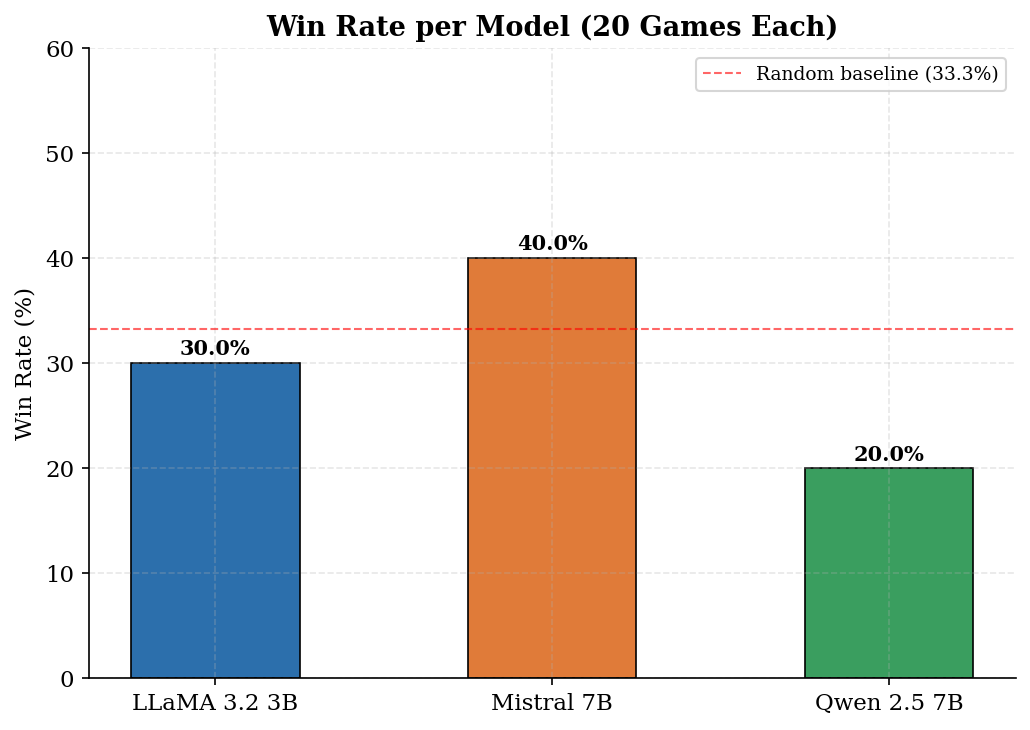

 Chart 1 saved: Win Rate


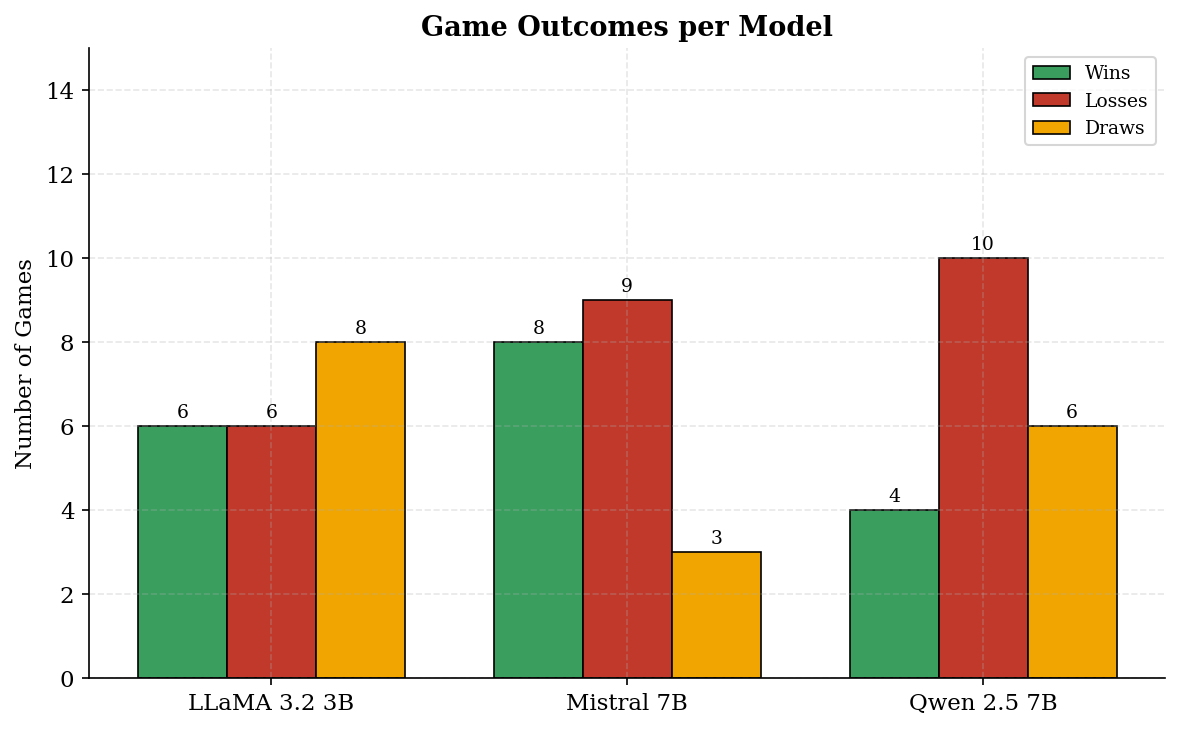

 Chart 2 saved: Game Outcomes


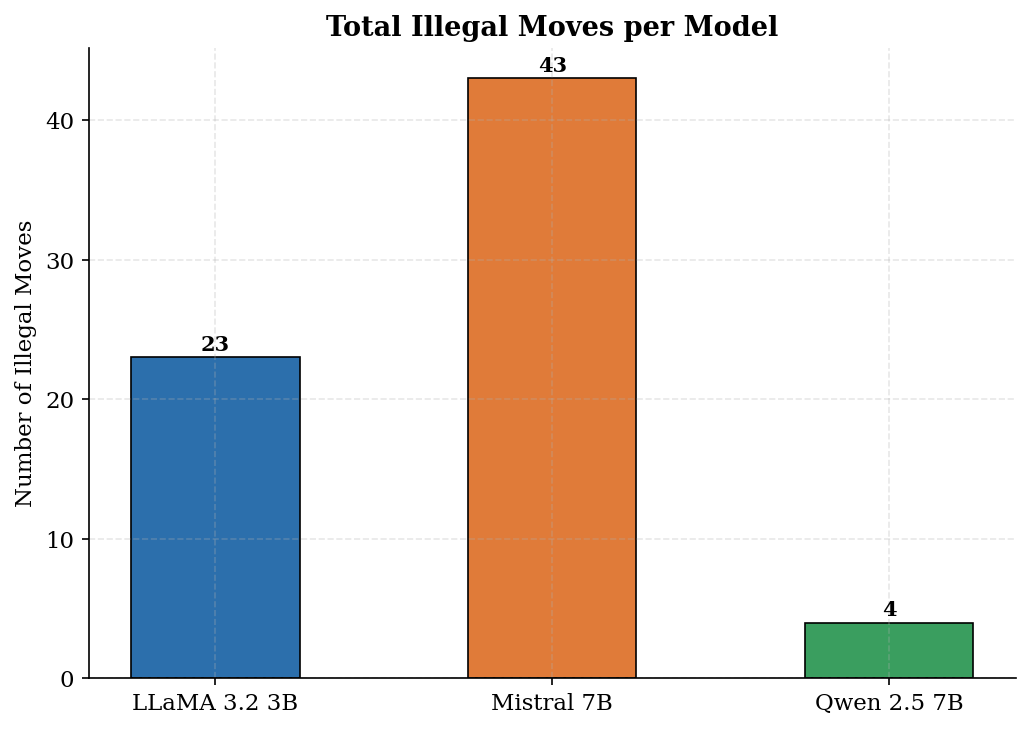

 Chart 3 saved: Illegal Moves


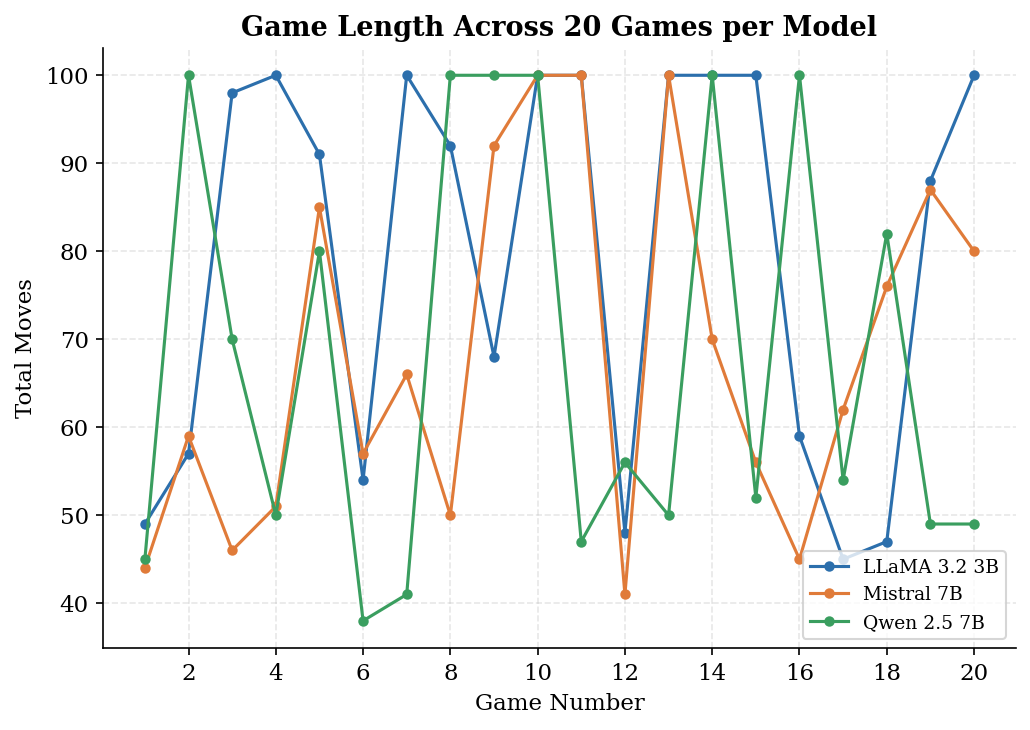

 Chart 4 saved: Game Length


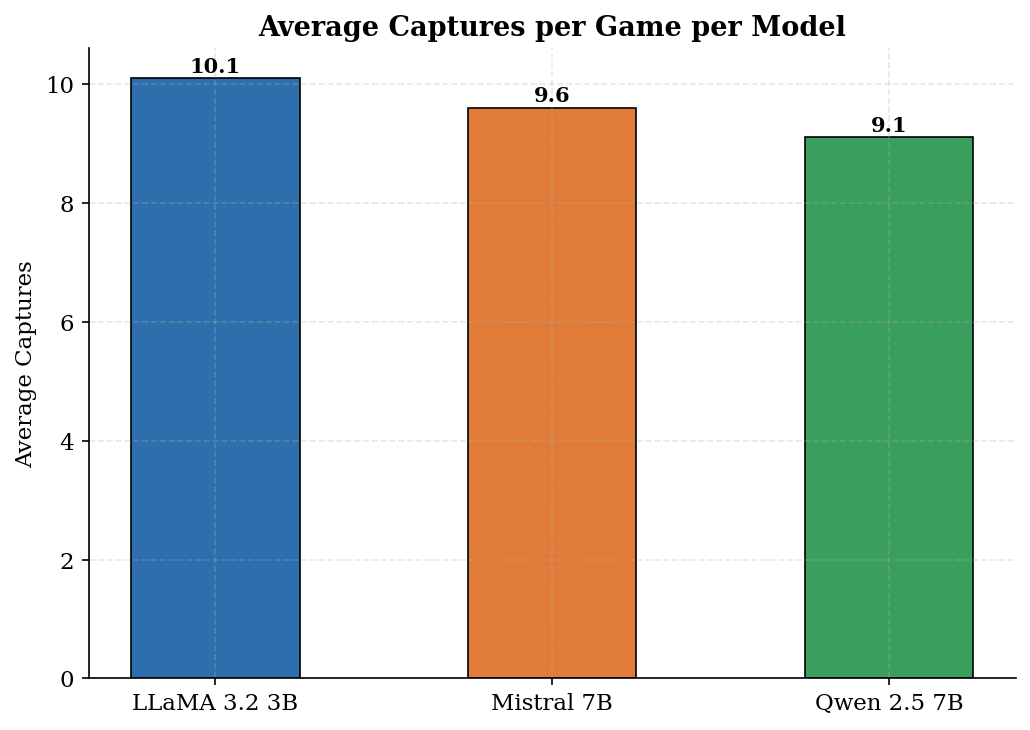

 Chart 5 saved: Captures


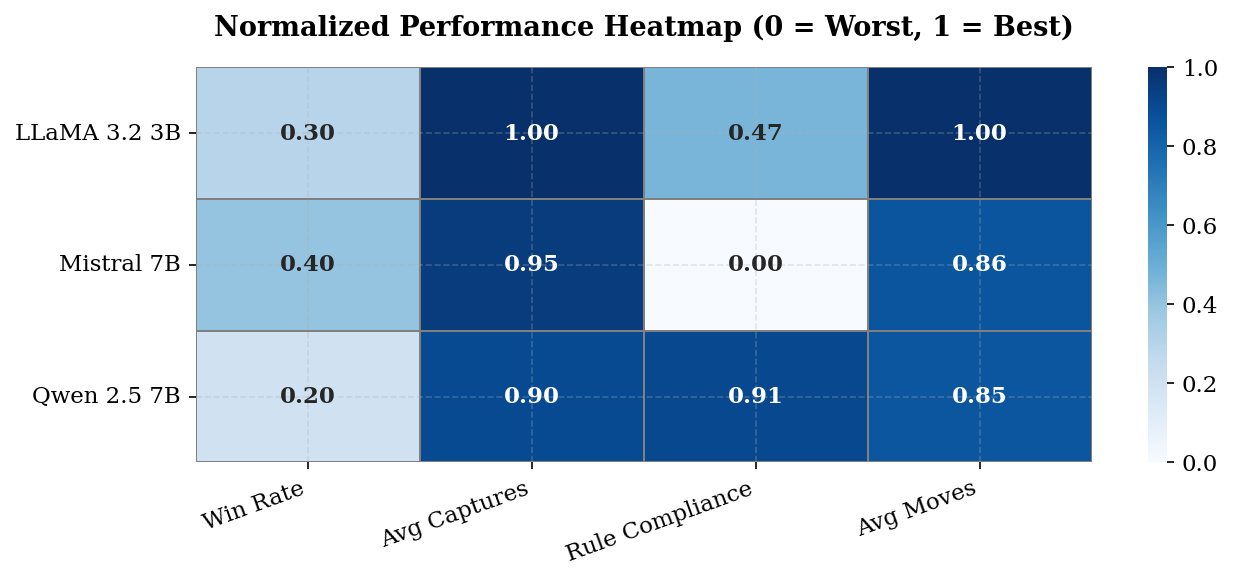

 Chart 6 saved: Heatmap

 All 6 charts saved to Google Drive!
   Location: /content/drive/MyDrive/checkers_benchmark


In [11]:
# ANALYSIS AND CHARTS


import subprocess
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

subprocess.run(["pip", "install", "seaborn", "-q"], check=True)
import seaborn as sns

# --- Rebuild DataFrame ---
summary = []
for model_name, results in all_results.items():
    wins          = sum(1 for r in results if r["winner"] == "RED")
    losses        = sum(1 for r in results if r["winner"] == "BLACK")
    draws         = sum(1 for r in results if r["winner"] == "DRAW")
    total_games   = len(results)
    win_rate      = round(wins / total_games * 100, 1)
    avg_moves     = round(sum(r["total_moves"] for r in results) / total_games, 1)
    avg_captures  = round(sum(r["captures_made"] for r in results) / total_games, 1)
    total_illegal = sum(r["illegal_moves"] for r in results)
    total_missed  = sum(r["missed_captures"] for r in results)

    summary.append({
        "Model"           : model_name,
        "Wins"            : wins,
        "Losses"          : losses,
        "Draws"           : draws,
        "Win Rate (%)"    : win_rate,
        "Avg Moves"       : avg_moves,
        "Avg Captures"    : avg_captures,
        "Illegal Moves"   : total_illegal,
        "Missed Captures" : total_missed
    })

df = pd.DataFrame(summary)

print(" DataFrame ready:")
print(df.to_string(index=False))
print()

# --- Academic Style ---
plt.rcParams.update({
    "font.family"       : "serif",
    "font.size"         : 11,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "figure.dpi"        : 150,
    "savefig.dpi"       : 150,
    "savefig.bbox"      : "tight"
})

models = df["Model"].tolist()
COLORS = ["#2C6FAC", "#E07B39", "#3A9E5F"]


# Chart 1: Win Rate

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, df["Win Rate (%)"],
              color=COLORS, edgecolor="black",
              linewidth=0.8, width=0.5)
ax.set_title("Win Rate per Model (20 Games Each)")
ax.set_ylabel("Win Rate (%)")
ax.set_ylim(0, 60)
ax.axhline(y=33.3, color="red", linestyle="--",
           linewidth=1, alpha=0.6, label="Random baseline (33.3%)")
for bar, val in zip(bars, df["Win Rate (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"{val}%", ha="center", fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/chart1_win_rate.png")
plt.show()
print(" Chart 1 saved: Win Rate")



# Chart 2: Wins Losses Draws

fig, ax = plt.subplots(figsize=(8, 5))
x     = np.arange(len(models))
width = 0.25
ax.bar(x - width, df["Wins"],   width, label="Wins",
       color="#3A9E5F", edgecolor="black", linewidth=0.8)
ax.bar(x,         df["Losses"], width, label="Losses",
       color="#C0392B", edgecolor="black", linewidth=0.8)
ax.bar(x + width, df["Draws"],  width, label="Draws",
       color="#F0A500", edgecolor="black", linewidth=0.8)
ax.set_title("Game Outcomes per Model")
ax.set_ylabel("Number of Games")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=9)
ax.set_ylim(0, 15)
for bars_group, vals in zip(
    [ax.containers[0], ax.containers[1], ax.containers[2]],
    [df["Wins"], df["Losses"], df["Draws"]]
):
    for bar, val in zip(bars_group, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                str(val), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/chart2_outcomes.png")
plt.show()
print(" Chart 2 saved: Game Outcomes")



# Chart 3: Illegal Moves

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, df["Illegal Moves"],
              color=COLORS, edgecolor="black",
              linewidth=0.8, width=0.5)
ax.set_title("Total Illegal Moves per Model")
ax.set_ylabel("Number of Illegal Moves")
for bar, val in zip(bars, df["Illegal Moves"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(val), ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/chart3_illegal_moves.png")
plt.show()
print(" Chart 3 saved: Illegal Moves")



# Chart 4: Game Length Line Chart

fig, ax = plt.subplots(figsize=(7, 5))
for i, (model_name, results) in enumerate(all_results.items()):
    game_moves = [r["total_moves"] for r in results]
    ax.plot(range(1, 21), game_moves,
            marker="o", markersize=4,
            label=model_name,
            color=COLORS[i],
            linewidth=1.5)
ax.set_title("Game Length Across 20 Games per Model")
ax.set_xlabel("Game Number")
ax.set_ylabel("Total Moves")
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/chart4_game_length.png")
plt.show()
print(" Chart 4 saved: Game Length")



# Chart 5: Average Captures

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, df["Avg Captures"],
              color=COLORS, edgecolor="black",
              linewidth=0.8, width=0.5)
ax.set_title("Average Captures per Game per Model")
ax.set_ylabel("Average Captures")
for bar, val in zip(bars, df["Avg Captures"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            str(val), ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/chart5_captures.png")
plt.show()
print(" Chart 5 saved: Captures")



# Chart 6: Performance Heatmap

fig, ax = plt.subplots(figsize=(9, 4))

heatmap_data = pd.DataFrame({
    "Win Rate"        : df["Win Rate (%)"].values / 100,
    "Avg Captures"    : df["Avg Captures"].values / df["Avg Captures"].max(),
    "Rule Compliance" : 1 - df["Illegal Moves"].values / df["Illegal Moves"].max(),
    "Avg Moves"       : df["Avg Moves"].values / df["Avg Moves"].max()
}, index=df["Model"].values)

sns.heatmap(
    heatmap_data,
    annot      = True,
    fmt        = ".2f",
    cmap       = "Blues",
    linewidths = 0.8,
    linecolor  = "grey",
    ax         = ax,
    vmin       = 0,
    vmax       = 1,
    annot_kws  = {"size": 11, "weight": "bold"}
)
ax.set_title("Normalized Performance Heatmap (0 = Worst, 1 = Best)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/chart6_heatmap.png")
plt.show()
print(" Chart 6 saved: Heatmap")

print("\n All 6 charts saved to Google Drive!")
print(f"   Location: {PROJECT_FOLDER}")